In [1]:
include("./trajopt/utils.jl")
include("./trajopt/dynamics.jl")
include("./funlopt/funl_dynamics.jl")
include("./funlopt/funl_utils.jl")
include("./funlopt/funl_constraint.jl")
include("./trajopt/scaling.jl")

compute_scaling (generic function with 1 method)

In [2]:
# load nominal trajectory
using JLD2, FileIO
filename = "./data/nominal_traj_unicycle_case4" 
@load filename my_dict
xnom = my_dict["x"]
unom = my_dict["u"]
tnom = my_dict["t"];
N = size(xnom,2) - 1
dtnom = zeros(N)
for i in 1:N
    dtnom[i] = tnom[i+1]-tnom[i]
end

In [3]:
function get_H_obs(rx,ry)
    return diagm([1/rx,1/ry])
end
c_list = []
H_list = []
# push!(c_list, [4.0, 2.5])
# push!(H_list, get_H_obs(1.5, 4.0))
# for i in [1.0,3.0,5.0,7.0]
# push!(c_list, [i, 2.0])
# push!(H_list, get_H_obs(0.2, 0.2))
# push!(c_list, [i, 4.0])
# push!(H_list, get_H_obs(0.2, 0.2))
# push!(c_list, [i, 6.0])
# push!(H_list, get_H_obs(0.2, 0.2))
# end

vmax = 2.0
vmin = 0.0
wmax = 1.5
wmin = -1.5
list_const = Vector{FunnelConstraint}()
push!(list_const,InputConstraint([1;0],vmax))
push!(list_const,InputConstraint([-1;0],-vmin))
push!(list_const,InputConstraint([0; 1],wmax))
push!(list_const,InputConstraint([0; -1],-wmin))
# for i = 1:length(c_list)
#     push!(list_const,ObstacleAvoidance(H_list[i],c_list[i]))
# end

4-element Vector{FunnelConstraint}:
 InputConstraint([1, 0], 2.0)
 InputConstraint([-1, 0], -0.0)
 InputConstraint([0, 1], 1.5)
 InputConstraint([0, -1], 1.5)

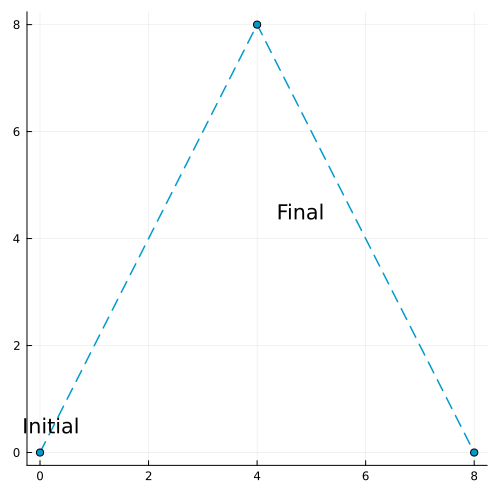

In [4]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
scatter!(xnom[1,:],xnom[2,:],c=:deepskyblue3,linewidth=1.5,label=nothing)
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
annotate!(0.2, 0.5, text("Initial", :black, :center))
annotate!(4.8, 4.5, text("Final", :black, :center))
display(p2)

In [5]:
ix = 3
iu = 2
iw = 2
dynamics = Unicycle()

Unicycle(3, 2, 2, 3, 2, 10, 5, 2, [0.0 0.0 1.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0; 1.0 0.0; 0.0 0.0], [1.0 0.0; 0.0 1.0; 0.0 0.0], [0.0 0.0; 0.0 0.0; 1.0 0.0], 0.01, 0.03, #undef, #undef, #undef, #undef)

In [6]:
A = zeros(ix,ix,N+1)
B = zeros(ix,iu,N+1)
F = zeros(ix,iw,N+1)
for idx in 1:N+1
    A[:,:,idx],B[:,:,idx],F[:,:,idx] = diff_ABF(dynamics,xnom[:,idx],unom[:,idx])
end

In [7]:
Qmax = zeros(ix,ix,N+1)
for idx in 1:N+1
    Qmax[:,:,idx] .= diagm([2^2,2^2,deg2rad(20)^2])
end
Rmax = get_Rmax_unicycle(unom,N,vmax,vmin,wmax,wmin)
;

In [8]:
include("./funlopt/funl_utils.jl")

propagate_from_funnel_entry_uncertain_dynamics (generic function with 1 method)

In [9]:
gamma_est = Lipschitz_estimation_around_traj(N,100,xnom,unom,dynamics,Qmax,Rmax)
gamma = gamma_est[1:N]

2-element Vector{Any}:
 [0.14264020973998265 0.0; 0.0 0.3089642775766438]
 [0.2789114051318561 0.0; 0.0 0.19559814526930316]

# Estimation of $\beta$

In [10]:
using Interpolations

In [11]:
u_fit = [LinearInterpolation(tnom, unom[idx,:],extrapolation_bc=Flat()) for idx in 1:iu]
A_fit = [[LinearInterpolation(tnom, A[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
B_fit = [[LinearInterpolation(tnom, B[i,j,:], extrapolation_bc=Flat()) for j in 1:iu] for i in 1:ix ]
F_fit = [[LinearInterpolation(tnom, F[i,j,:], extrapolation_bc=Flat()) for j in 1:iw] for i in 1:ix ];
function get_u_interp(t::Float64)
    ans = zeros(iu)
    for i in 1:iu
        ans[i] = u_fit[i](t)
    end
    return ans
end
function get_ABF_interp(t::Float64,Q_fit,n,m)::Array{Float64,2}
    new_Q_matrix = Array{Float64}(undef, n, m)
    for i in 1:n
        for j in 1:m
            new_Q_matrix[i, j] = Q_fit[i][j](t)
        end
    end
    return new_Q_matrix
end

get_ABF_interp (generic function with 1 method)

In [12]:
function model_wrapper!(f,x,p,t)
    um = p[1]
    up = p[2]
    dt = p[3]
    alpha = (dt - t) / dt
    beta = t / dt
    u1 = alpha*um + beta*up
    f .= forward(dynamics,x,u1)
end

model_wrapper! (generic function with 1 method)

In [13]:
N_sampling = 20
beta = []
for i = 1:N
    tspan = (0,tnom[i+1]-tnom[i])
    saveat = range(0, stop=tnom[i+1]-tnom[i], length=N_sampling)
    prob = ODEProblem(model_wrapper!,xnom[:,i],tspan,(unom[:,i],unom[:,i+1],tnom[i+1]-tnom[i]),saveat = saveat)
    sol = solve(prob, Tsit5(), reltol=1e-9, abstol=1e-9;verbose=false);
    @assert(isapprox(sol.u[end],xnom[:,i+1];atol=0.001))
    delta = []
    for idx_sample = 1:N_sampling
        t_eval = sol.t[idx_sample] + tnom[i]
        x_eval = sol.u[idx_sample]
        u_eval = get_u_interp(t_eval)
        A_eval,B_eval,F_eval = diff_ABF(dynamics,x_eval,u_eval)
        eA = get_ABF_interp(t_eval,A_fit,ix,ix) .- A_eval
        eB = get_ABF_interp(t_eval,B_fit,ix,iu) .- B_eval
        eF = get_ABF_interp(t_eval,F_fit,ix,iw) .- F_eval
        delta_ = [eA eB eF]
        push!(delta,opnorm(delta_,2))
    end
    push!(beta,maximum(delta))
end
beta

2-element Vector{Any}:
 2.0338659573323956
 2.033865957800012

In [14]:
# dynamics.C = [1.0I(ix);zeros(iu,ix);zeros(iw,ix);dynamics.Co]
# dynamics.D = [zeros(ix,iu);1.0I(iu);zeros(iw,iu);dynamics.Do]
# dynamics.E = [1.0I(ix) dynamics.Eo]
# dynamics.G = [zeros(ix,iw);zeros(iu,iw);1.0I(iw);dynamics.Go];
C1 = [0 0 1;0 0 0]
D1 = [1 0;0 0]
G1 = [0 0;0 0]
E1 = [1 0;0 1;0 0]

dynamics.C = [C1;dynamics.Co]
dynamics.D = [D1;dynamics.Do]
dynamics.E = [E1 dynamics.Eo]
dynamics.G = [G1;dynamics.Go];

dynamics.ir = 2 + dynamics.iq
dynamics.ip = 2 + dynamics.iphi

4

In [15]:
xmin = [0;0;0];
xmax = [1;1;pi];
umin = [0;0];
umax = [1;1];
scaler = Scaling(xmin, xmax, umin, umax, 1e3,1e3)

Scaling([1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 3.141592653589793], [1.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 0.3183098861837907], [0.0, 0.0, 0.0], [1.0 0.0; 0.0 1.0], [1.0 0.0; 0.0 1.0], [0.0, 0.0], [1000.0 0.0; 0.0 1000.0], 1.0)

In [16]:
include("./funlopt/funl_synthesis.jl")

run! (generic function with 1 method)

In [19]:
# lambda_w = 2.0
list_lambda_w = [1e-3,0.01,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,1.0,1.2,1.4,1.6,2.0,10.0,1e2,1e3,1e4]
cost_lambda_w = []
list_fs = []
println("Line search for lambda_w from 0.01 to 2.0")
for lambda_w in list_lambda_w
        fs = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,
                verbosity=false,
                flag_copositivity_type=1)
        cost,solve_time = run!(fs,
        1.0*gamma,
        0.0*beta,
        xnom,unom,tnom,Qmax,Rmax,"Mosek")
        println("lambda_w: ",lambda_w, " cost: ",abs(cost) < 1e-6 ? "diverged" : cost)
        push!(cost_lambda_w,cost)
        push!(list_fs,fs)
end
idx_lambda_w = 1:length(list_lambda_w)
idx_converged = abs.(cost_lambda_w) .>= 1e-6
cost_lambda_w_converged = cost_lambda_w[idx_converged]
idx_fs = argmin(cost_lambda_w_converged)
idx_min = idx_lambda_w[idx_converged][idx_fs]

lambda_w = list_lambda_w[idx_min]
cost = cost_lambda_w[idx_min]
fs = list_fs[idx_min]

println(lambda_w," is picked. The corresponding cost is ",cost)

Line search for lambda_w from 0.01 to 2.0
lambda_w: 0.001 cost: diverged
lambda_w: 0.01 cost: diverged
lambda_w: 0.1 cost: diverged
lambda_w: 0.2 cost: 1.4929305809351812
lambda_w: 0.3 cost: 0.3230792359695732
lambda_w: 0.4 cost: 0.13237528951788205
lambda_w: 0.5 cost: 0.0797375369098648
lambda_w: 0.6 cost: 0.06560684002392432
lambda_w: 0.7 cost: 0.06334754000758361
lambda_w: 0.8 cost: 0.06478623616660278
lambda_w: 1.0 cost: 0.07003615191389224
lambda_w: 1.2 cost: 0.07647955048400656
lambda_w: 1.4 cost: diverged
lambda_w: 1.6 cost: diverged
lambda_w: 2.0 cost: diverged
lambda_w: 10.0 cost: diverged
lambda_w: 100.0 cost: diverged
lambda_w: 1000.0 cost: diverged
lambda_w: 10000.0 cost: diverged
0.7 is picked. The corresponding cost is 0.06334754000758361


In [20]:
fs2 = FunnelSynthesis(N,lambda_w,dynamics,list_const,scaler,verbosity=false,flag_copositivity_type=2)
cost = run!(fs2,
1.0*gamma,
0.0*beta,
xnom,unom,tnom,Qmax,Rmax,"Mosek")
println("lambda_w: ",lambda_w, " cost: ",cost)

lambda_w: 0.7 cost: (0.06334495393709667, 0.16181206703186035)


In [21]:
Qnom_,Ynom_,lamnom_ = fs.solution.Q,fs.solution.Y,fs.solution.lam
Qnom,Ynom,lamnom = fs2.solution.Q,fs2.solution.Y,fs2.solution.lam

([0.29114481573789025 -2.0891866888544398e-5 1.116212267319196e-5; -2.0891866888544398e-5 0.24805248636025473 -0.16635287332483134; 1.116212267319196e-5 -0.16635287332483134 0.11447129406671984;;; 0.07874929716583813 -1.1576960995586109e-5 1.430940926151947e-6; -1.1576960995586109e-5 0.5328438189964392 -0.23076459295156093; 1.430940926151947e-6 -0.23076459295156093 0.10648751700780439;;; 0.48275764385794534 1.7297026582206983e-5 -2.311225390976701e-5; 1.7297026582206983e-5 0.11576514147106529 -0.11417620381265907; -2.311225390976701e-5 -0.11417620381265907 0.11849076477295088], [-0.3394663833529595 8.402899604502817e-7 2.133479011771024e-6; -3.42237414868934e-6 0.0179482569175791 -0.04568860497892481;;; -0.0574302388810356 7.624030640849136e-6 -4.0030041327908377e-7; -2.759443953746047e-6 -0.007124536681314534 -0.04747692528379152;;; -0.4468658587262311 1.1303757823261172e-5 -9.274009529165768e-6; 2.6956341527675597e-5 -0.0019560442122148894 -0.04599822679302341], [9673.16300053468 586

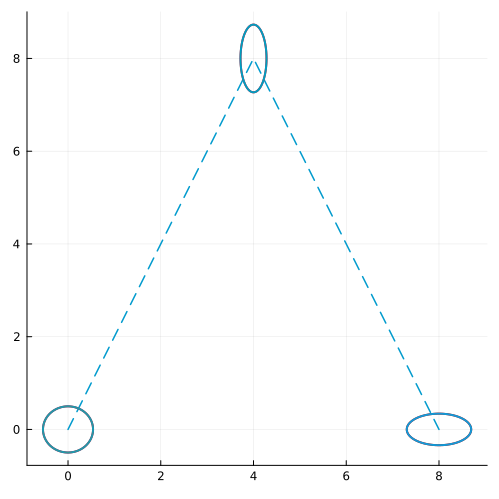

In [22]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:N+1
    label = nothing
    # if idx == 1
    #     label = "funnel"
    # end
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"red",label=label,fill=false)
    plot_ellipse(p2,Qnom_[:,:,idx],xnom[:,idx],"deepskyblue3",label=label,fill=false)
end
# plot_ellipse(p2,fs.solution.Qi,xnom[:,1],"green3",label="initial and final")
# plot_ellipse(p2,fs.solution.Qf,xnom[:,end],"green3")
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
display(p2)

In [23]:
function project_onto_input(Q,Y) 
    R = zeros(iu,iu,size(Q,3))
    for i in 1:size(Q,3)
        K = Y[:,:,i] * inv(Q[:,:,i])
        # push!(R,)
        R[:,:,i] .= K*Q[:,:,i]*K'
    end
    projected_input_funl = []
    for j in 1:iu
        a = zeros(iu)
        a[j] = 1
        each_funl = []
        for i in 1:size(Q,3)
            push!(each_funl,sqrt(a'*R[:,:,i]*a))
        end
        push!(projected_input_funl,each_funl)
    end
    return projected_input_funl,R
end

project_onto_input (generic function with 1 method)

In [24]:
input_proj_funl_node,Rnom = project_onto_input(Qnom,Ynom)

(Any[Any[0.6291326787604391, 0.20465260617496617, 0.6431504831788536], Any[0.624960613069481, 0.6249359206864533, 0.6249588262698386]], [0.39580792748428584 9.512778787892075e-6; 9.512778787892073e-6 0.39057576788818155;;; 0.0418826892142058 -2.0559961319795773e-7; -2.0559961319796686e-7 0.3905449049642251;;; 0.4136425440131929 4.964514975333748e-6; 4.9645149753336915e-6 0.3905735345325743])

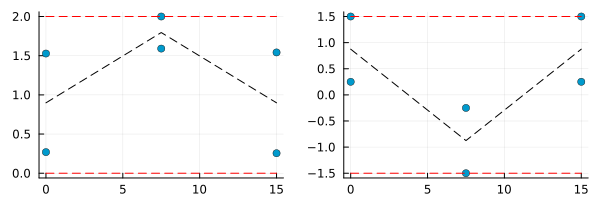

In [25]:
p1 = plot(tnom,unom[1,:],linestyle=:dash,color="black",label="")
scatter!(tnom,unom[1,:]+input_proj_funl_node[1],color="deepskyblue3",label="")
scatter!(tnom,unom[1,:]-input_proj_funl_node[1],color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ vmin,linestyle=:dash,color="red",label="")
p2 = plot(tnom,unom[2,:],linestyle=:dash,color="black",label="")
scatter!(tnom,unom[2,:]+input_proj_funl_node[2],color="deepskyblue3",label="")
scatter!(tnom,unom[2,:]-input_proj_funl_node[2],color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ wmin,linestyle=:dash,color="red",label="")
plot(p1,p2,layout=(1,2),size=(600,200))

# samples

In [26]:
Q_fit = [[LinearInterpolation(tnom, Qnom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:ix ]
Y_fit = [[LinearInterpolation(tnom, Ynom[i,j,:], extrapolation_bc=Flat()) for j in 1:ix] for i in 1:iu ]
# function get_QY_interp(t::Float64,Q_fit,n,m)::Array{Float64,2}
#     new_Q_matrix = Array{Float64}(undef, n, m)
#     for i in 1:n
#         for j in 1:m
#             new_Q_matrix[i, j] = Q_fit[i][j](t)
#         end
#     end
#     return new_Q_matrix
# end
;

In [27]:
include("./funlopt/funl_utils.jl")

propagate_from_funnel_entry_uncertain_dynamics (generic function with 1 method)

In [28]:
num_sample = 100
xs_list = []
for i in 1:num_sample
    z = randn(ix)
    z = z / norm(z)
    push!(xs_list,xnom[:,1] + sqrt(Qnom[:,:,1]) * z)
end

In [29]:
xsam_fwd,tsam,xsam,usam,xnomprop = [],[],[],[],[]
i = 0
for xs in xs_list
    # println(i)
    i += 1
    xf_,ts_,xsam_,usam_,xnom_ = propagate_from_funnel_entry_uncertain_dynamics(xs,
        dynamics,
        xnom,unom,tnom,
        Qnom,Ynom)
    push!(xsam_fwd,xf_)
    push!(tsam,ts_)
    push!(xsam,xsam_)
    push!(usam,usam_)
    push!(xnomprop,xnom_)
end

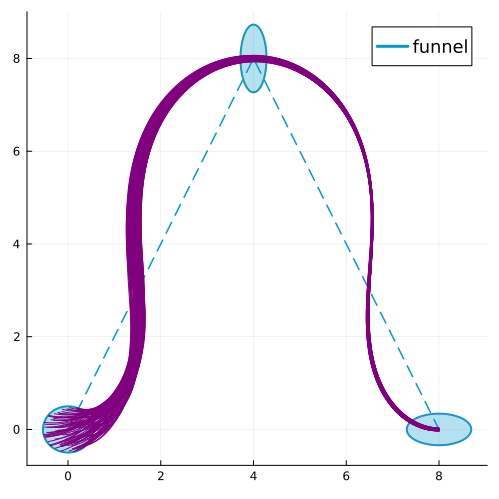

In [30]:
p2 = Plots.plot(; size=(500,500))
plot!(xnom[1,:],xnom[2,:],aspect_ratio=:equal,c=:deepskyblue3,linestyle=:dash,linewidth=1.5,label=nothing)
for idx in 1:N+1
    label = nothing
    if idx == 1
        label = "funnel"
    end
    plot_ellipse(p2,Qnom[:,:,idx],xnom[:,idx],"deepskyblue3",label=label)
end
# plot_ellipse(p2,fs.solution.Qi,xnom[:,1],"green3",label="initial and final")
# plot_ellipse(p2,fs.solution.Qf,xnom[:,end],"green3")
for (idx,(ce, H)) in enumerate(zip(c_list, H_list))
    label = nothing
    if idx == 1
        label = "obstacle"
    end
    plot_ellipse(p2,inv(H)*inv(H),ce,"red3",label=label)
end
for x_ in xsam
    plot!(x_[1,:],x_[2,:],color="purple",label=nothing)
end
display(p2)

In [31]:
# Lyapunov function
Lypsam = []
idx = 1
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    xprop_ = xnomprop[idx]
    Lyp = []
    for iode in 1:length(tsam_)
        t_ = tsam_[iode]
        x_ = xsam_[:,iode]
        xnom_ = xprop_[:,iode]
        Q_ = get_ABF_interp(t_,Q_fit,ix,ix)
        val = (x_ - xnom_)' * inv(Q_) * (x_ - xnom_)
        push!(Lyp,val)
    end
    push!(Lypsam,Lyp)
end


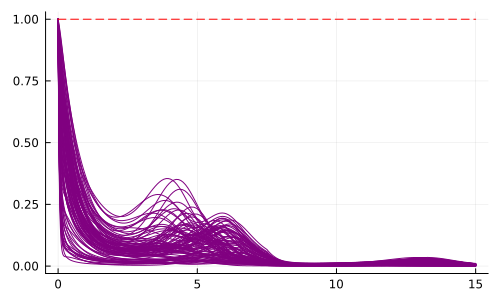

In [32]:
p3 = Plots.plot(; size=(500,300))
for idx = 1:length(tsam)
    plot!(tsam[idx],Lypsam[idx],c=:purple,label="")
end
plot!(tsam[1],tsam[1]*0 .+ 1.0,c=:red,linestyle=:dash,label="")
display(p3)

In [ ]:
p1 = plot(tsam[1],xnomprop[1][1,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[1,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[1,:] + sqrt.(Qnom[1,1,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[1,:] - sqrt.(Qnom[1,1,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[1,:],color="purple",label="")
end
p2 = plot(tsam[1],xnomprop[1][2,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[2,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[2,:] + sqrt.(Qnom[2,2,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[2,:] - sqrt.(Qnom[2,2,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[2,:],color="purple",label="")
end
p3 = plot(tsam[1],xnomprop[1][3,:],linestyle=:dash,color="black",label="")
scatter!(tnom,xnom[3,:],linestyle=:dash,color="black",label="")
plot!(tnom,xnom[3,:] + sqrt.(Qnom[3,3,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,xnom[3,:] - sqrt.(Qnom[3,3,:]),seriestype = :line, marker = :circle,color="deepskyblue3",label="")
for idx = 1:length(tsam)
    tsam_ = tsam[idx]
    xsam_ = xsam[idx]
    plot!(tsam_,xsam_[3,:],color="purple",label="")
end
plot(p1,p2,p3,layout=(3,1),size=(600,400))

In [ ]:
length_idx = length(tsam)
p1 = plot(tnom,unom[1,:],linestyle=:dash,color="black",label="")
plot!(tnom,unom[1,:]+input_proj_funl_node[1],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,unom[1,:]-input_proj_funl_node[1],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ vmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ vmin,linestyle=:dash,color="red",label="")
for idx = 1:length_idx
    tsam_ = tsam[idx]
    usam_ = usam[idx]
    plot!(tsam_,usam_[1,:],color="purple",label="")
end
p2 = plot(tnom,unom[2,:],linestyle=:dash,color="black",label="")
plot!(tnom,unom[2,:]+input_proj_funl_node[2],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,unom[2,:]-input_proj_funl_node[2],seriestype = :line, marker = :circle,color="deepskyblue3",label="")
plot!(tnom,tnom*0 .+ wmax,linestyle=:dash,color="red",label="")
plot!(tnom,tnom*0 .+ wmin,linestyle=:dash,color="red",label="")
for idx = 1:length_idx
    tsam_ = tsam[idx]
    usam_ = usam[idx]
    plot!(tsam_,usam_[2,:],color="purple",label="")
end
plot(p1,p2,layout=(1,2),size=(800,400))